# Linear Regression from Scratch

This notebook implements simple and multiple linear regression from scratch using only NumPy and Matplotlib.

## Mathematical Foundations
Linear regression models the relationship between dependent variable $y$ and independent variables $X$:
$$y = Xw + b$$

We optimize the parameters $w$ (weights) and $b$ (bias) by minimizing the Mean Squared Error (MSE) cost function:
$$J(w, b) = \frac{1}{2m} \sum_{i=1}^{m} (y^{(i)} - \hat{y}^{(i)})^2$$

Using Gradient Descent, we update the parameters iteratively:
$$w := w - \alpha \frac{\partial J}{\partial w}$$
$$b := b - \alpha \frac{\partial J}{\partial b}$$

Where the gradients are:
$$\frac{\partial J}{\partial w} = \frac{1}{m} X^T (\hat{y} - y)$$
$$\frac{\partial J}{\partial b} = \frac{1}{m} \sum_{i=1}^{m} (\hat{y}^{(i)} - y^{(i)})$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Set random seed for reproducibility
np.random.seed(42)

## Generate Synthetic Data

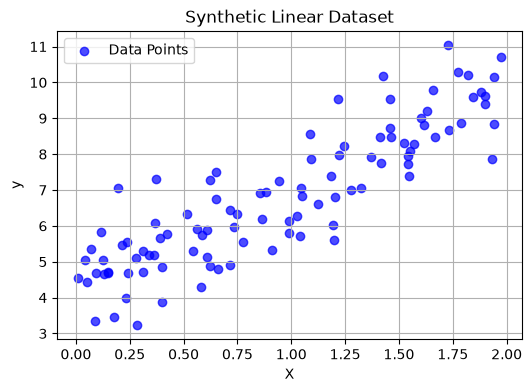

In [2]:
X = 2 * np.random.rand(100, 1)
y = 4 + 3 * X + np.random.randn(100, 1)

plt.figure(figsize=(6, 4))
plt.scatter(X, y, color='blue', alpha=0.7, label='Data Points')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Synthetic Linear Dataset')
plt.legend()
plt.grid(True)
plt.show()

## Linear Regression Implementation

In [3]:
class LinearRegressionFromScratch:
    def __init__(self, learning_rate=0.01, iterations=1000):
        self.lr = learning_rate
        self.iterations = iterations
        self.w = None
        self.b = None
        self.loss_history = []
        
    def fit(self, X, y):
        m, n = X.shape
        self.w = np.zeros((n, 1))
        self.b = 0.0
        self.loss_history = []
        
        for i in range(self.iterations):
            y_pred = self.predict(X)
            loss = self.compute_loss(y, y_pred)
            self.loss_history.append(loss)
            
            # Compute gradients
            dw = (1 / m) * np.dot(X.T, (y_pred - y))
            db = (1 / m) * np.sum(y_pred - y)
            
            # Update parameters
            self.w -= self.lr * dw
            self.b -= self.lr * db
            
            if i % 100 == 0:
                print(f"Iteration {i:4d}: Loss = {loss:.4f}")
                
    def predict(self, X):
        return np.dot(X, self.w) + self.b
        
    def compute_loss(self, y_true, y_pred):
        return np.mean((y_true - y_pred) ** 2)

## Train the Model

In [4]:
model = LinearRegressionFromScratch(learning_rate=0.1, iterations=500)
model.fit(X, y)

Iteration    0: Loss = 50.0083
Iteration  100: Loss = 0.8163
Iteration  200: Loss = 0.8069
Iteration  300: Loss = 0.8066
Iteration  400: Loss = 0.8066


## Plot Results

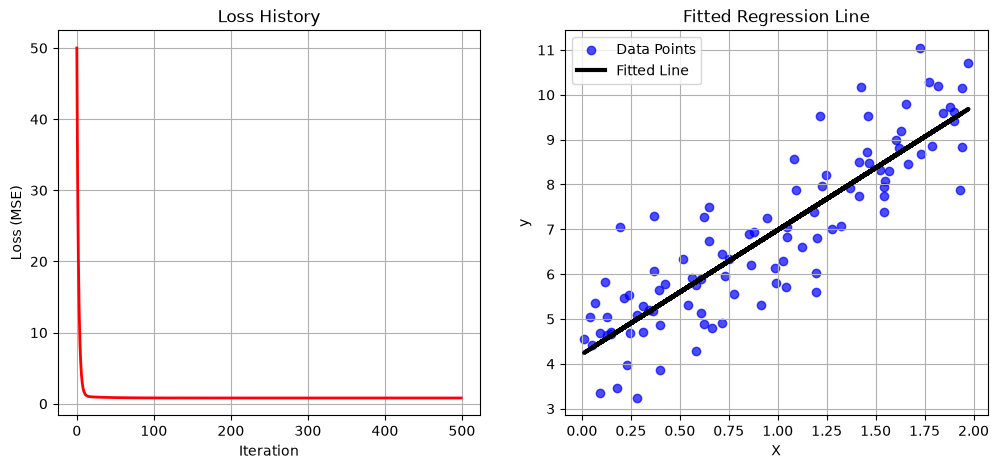

In [5]:
plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(model.loss_history, color='red', lw=2)
plt.xlabel('Iteration')
plt.ylabel('Loss (MSE)')
plt.title('Loss History')
plt.grid(True)

plt.subplot(1, 2, 2)
plt.scatter(X, y, color='blue', alpha=0.7, label='Data Points')
plt.plot(X, model.predict(X), color='black', lw=3, label='Fitted Line')
plt.xlabel('X')
plt.ylabel('y')
plt.title('Fitted Regression Line')
plt.legend()
plt.grid(True)

plt.show()